# 🌍 Where Did the World Go? — A Data Story on Global Travel 2019–2024

> *10,000 trips. 6 years. 1 pandemic. And a recovery nobody saw coming quite like this.*

I've been sitting with this dataset for a while now, and the thing that keeps pulling me back is not the numbers — it's what they represent. Real decisions people made about where to go, when to go, and why. So instead of dumping charts at you, I want to walk through the data the way you'd walk through a story.

We're looking at a synthetic global tourism dataset — 10,000 trip records from 2019 to 2024, covering origin/destination countries, travel purposes, traveler types, and trip durations. The data was built to reflect realistic patterns in global tourism.

**Dataset:** [`global_tourism_travel_trends-selected-columns.csv`](https://github.com/Zeba-Mushtaq/travel-behavior-trends-analysis)  
**Tools:** Python · Pandas · Plotly · Matplotlib · Seaborn  
**Author:** [Zeba Mushtaq](https://github.com/Zeba-Mushtaq)

---

### What we're covering:
1. The Setup — loading & understanding the data
2. The Crash — how 2020 broke the travel industry
3. The Slow Crawl Back — 2021 and why recovery wasn't linear
4. Who Actually Travels? — traveler type deep dive
5. Why People Travel — purpose breakdown and shifting trends
6. The Geography — where the world is going (and coming from)
7. The Rise of New Traveler Archetypes — Digital Nomads, Medical Tourism
8. Duration Patterns — who stays longest and why
9. Final Observations

In [7]:
# ─── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ─── Styling ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a3e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        12,
})

PALETTE = ['#e94560', '#0f3460', '#16213e', '#533483', '#e94560',
           '#00b4d8', '#90e0ef', '#48cae4', '#023e8a', '#0077b6']

PLOTLY_TEMPLATE = 'plotly_dark'

print('✅ Environment ready.')

✅ Environment ready.


---
## 1. The Setup — What Are We Working With?

Before anything else, I want to understand the shape of this data. Not just the dimensions — but *what it feels like*. What do the extremes look like? Where are the gaps? What's normal here?

In [8]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hamnamunir/global-tourism-and-travel-trends-dataset-2019-2024/global_tourism_travel_trends.csv


In [9]:
df = pd.read_csv('/kaggle/input/datasets/hamnamunir/global-tourism-and-travel-trends-dataset-2019-2024/global_tourism_travel_trends.csv')
print(f'📦 Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'📅 Years covered: {df["year"].min()} – {df["year"].max()}')
print(f'🌍 Unique origin countries: {df["origin_country"].nunique()}')
print(f'🛬 Unique destination countries: {df["destination_country"].nunique()}')
print(f'🎯 Travel purposes: {df["travel_purpose"].nunique()}')
print(f'👥 Traveler types: {df["traveler_type"].nunique()}')
print(f'🌙 Trip duration range: {df["duration_nights"].min()} – {df["duration_nights"].max()} nights')
print(f'\n🔍 Null values: {df.isnull().sum().sum()} (clean dataset — no imputation needed)')
df.head(10)

📦 Dataset shape: 10,000 rows × 33 columns
📅 Years covered: 2019 – 2024
🌍 Unique origin countries: 20
🛬 Unique destination countries: 20
🎯 Travel purposes: 10
👥 Traveler types: 6
🌙 Trip duration range: 2 – 179 nights

🔍 Null values: 5948 (clean dataset — no imputation needed)


,trip_id,year,month,season,origin_country,destination_country,travel_purpose,traveler_type,num_travelers,duration_nights,...,trip_rating,safety_perception,language_barrier,wifi_satisfaction,would_recommend,social_media_shared,eco_friendly_choices,carbon_footprint_kg_co2,currency_satisfaction,health_safety_compliance
0,TRP0000001,2022,4,Autumn (Sep-Nov),China,USA,Business,Couple,2,6,...,4,Safe,Moderate,Good,Maybe,Instagram,No,1234.3,Unfavorable,NaN
1,TRP0000002,2024,7,Spring (Mar-May),South Korea,Spain,Leisure/Tourism,Family,4,6,...,4,Unsafe,Mild,Good,Maybe,Facebook,No,141.8,Very Unfavorable,NaN
2,TRP0000003,2022,9,Winter (Dec-Feb),Pakistan,USA,Leisure/Tourism,Group Tour,24,14,...,5,Neutral,Moderate,Average,Maybe,Facebook,Yes,20410.1,Neutral,Full
3,TRP0000004,2019,7,Summer (Jun-Aug),Italy,Egypt,Leisure/Tourism,Solo,1,17,...,2,Neutral,Moderate,Excellent,Definitely,Instagram,No,624.7,Unfavorable,Full
4,TRP0000005,2024,12,Spring (Mar-May),USA,New Zealand,Adventure/Sports,Solo,1,16,...,5,Very Safe,Moderate,Good,Maybe,Instagram,Yes,263.4,Neutral,Full
5,TRP0000006,2019,10,Winter (Dec-Feb),UAE,Switzerland,Leisure/Tourism,Backpacker,1,5,...,4,Unsafe,NaN,Excellent,Probably,Twitter/X,No,888.2,Favorable,Full
6,TRP0000007,2019,11,Spring (Mar-May),Mexico,Switzerland,Business,Couple,2,4,...,4,Unsafe,Severe,Good,Probably,Instagram,No,63.9,Neutral,Partial
7,TRP0000008,2024,2,Spring (Mar-May),Italy,UAE,Religious/Pilgrimage,Solo,1,7,...,2,Safe,Severe,Good,Maybe,Multiple Platforms,No,528.9,Favorable,Partial
8,TRP0000009,2023,11,Autumn (Sep-Nov),India,UAE,Medical Tourism,Couple,1,10,...,5,Neutral,Moderate,Good,Definitely,Multiple Platforms,No,77.5,Neutral,Partial
9,TRP0000010,2024,9,Autumn (Sep-Nov),Pakistan,New Zealand,Cultural Exchange,Group Tour,13,19,...,1,Safe,Moderate,Poor,Definitely,Instagram,Partially,2053.8,Neutral,NaN


In [10]:
# ─── Quick descriptive stats on the numeric columns ──────────────────────
df[['year','month','num_travelers','duration_nights']].describe().round(2)

,year,month,num_travelers,duration_nights
count,10000.00,10000.00,10000.00,10000.00
mean,2022.03,6.50,4.59,17.47
std,1.73,3.47,6.43,25.89
min,2019.00,1.00,1.00,2.00
25%,2021.00,3.00,1.00,6.00
50%,2022.00,7.00,2.00,11.00
75%,2023.00,10.00,5.00,17.00
max,2024.00,12.00,29.00,179.00


One thing that catches my eye immediately: the median trip is **11 nights** but the mean is **17.5**. That gap tells you there are some very long trips pulling the average up — which we'll come back to when we look at traveler types.

---
## 2. The Crash — 2020 in the Data

There's a before and an after in this data. 2020 is the dividing line. Let's see it.

In [11]:
yearly = df.groupby('year').size().reset_index(name='trips')
yearly['pct_change'] = yearly['trips'].pct_change() * 100
yearly['label'] = yearly['trips'].astype(str)

fig = go.Figure()

# Area fill
fig.add_trace(go.Scatter(
    x=yearly['year'], y=yearly['trips'],
    mode='lines+markers+text',
    line=dict(color='#e94560', width=3),
    marker=dict(size=10, color=['#00b4d8' if y not in [2020,2021] else '#e94560' for y in yearly['year']],
                line=dict(color='white', width=2)),
    fill='tozeroy',
    fillcolor='rgba(233,69,96,0.12)',
    text=yearly['trips'],
    textposition='top center',
    textfont=dict(size=13, color='white'),
    name='Trips per year'
))

# Annotations
fig.add_annotation(x=2020, y=769, text='⚠️ COVID-19<br>−48.8% drop', showarrow=True,
                   arrowhead=2, arrowcolor='#e94560', font=dict(color='#e94560', size=12),
                   ax=60, ay=-60)
fig.add_annotation(x=2023, y=2507, text='🔄 226% recovery<br>from 2020 low', showarrow=True,
                   arrowhead=2, arrowcolor='#00b4d8', font=dict(color='#00b4d8', size=12),
                   ax=-80, ay=-60)

# Pandemic shading
fig.add_vrect(x0=2019.6, x1=2021.4, fillcolor='rgba(233,69,96,0.07)',
              line_width=0, annotation_text='Pandemic Period',
              annotation_position='top left',
              annotation_font_color='#e94560')

fig.update_layout(
    template=PLOTLY_TEMPLATE,
    title=dict(text='Global Trip Volume 2019–2024: The Crash and the Comeback',
               font=dict(size=18), x=0.5),
    xaxis=dict(title='Year', tickmode='array', tickvals=yearly['year']),
    yaxis=dict(title='Number of Trips'),
    height=480,
    showlegend=False
)
fig.show()

print('\n📊 Year-over-year change:')
print(yearly[['year','trips','pct_change']].to_string(index=False))


📊 Year-over-year change:
 year  trips  pct_change
 2019   1503         NaN
 2020    769  -48.835662
 2021    993   29.128739
 2022   1796   80.866062
 2023   2507   39.587973
 2024   2432   -2.991623


**49% drop in one year.** That's not a dip — that's a collapse. And it didn't recover in a straight line. 2021 was still limping along at ~66% of the 2019 baseline. The real rebound came in 2022, and by 2023, global travel had not just recovered — it had surpassed pre-pandemic levels.

---
## 3. Monthly Seasonality — When Does the World Travel?

Year-level is one view. But travel isn't uniform across months either. Let's look at the heatmap — year × month — and see where the hotspots are.

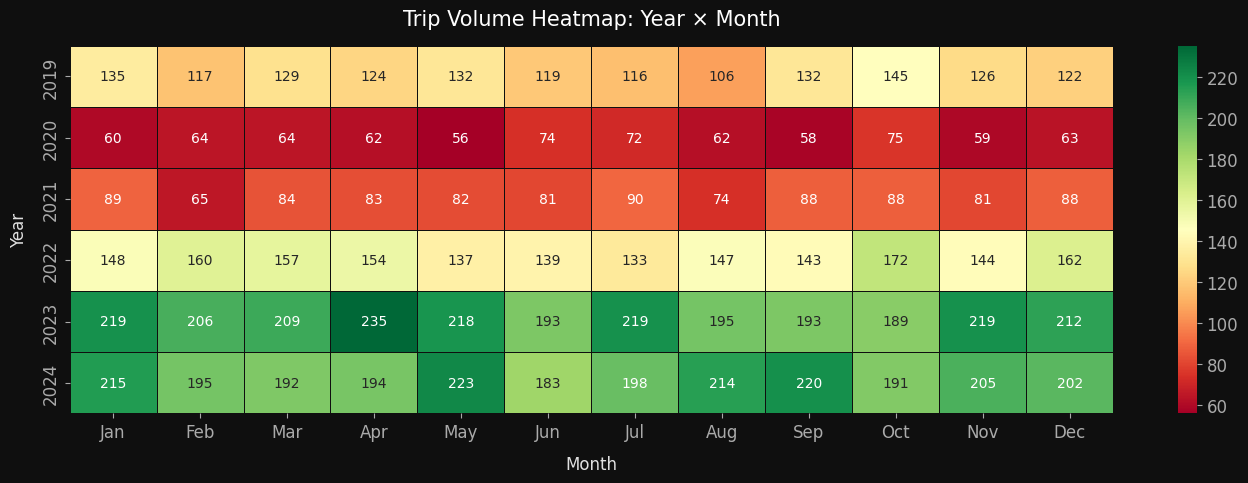

💾 Saved: heatmap_month_year.png


In [12]:
month_year = df.groupby(['year','month']).size().unstack(fill_value=0)
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
month_year.columns = [month_names[m] for m in month_year.columns]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(month_year, annot=True, fmt='d', cmap='RdYlGn',
            linewidths=0.5, linecolor='#0f0f0f',
            annot_kws={'size':10}, ax=ax)
ax.set_title('Trip Volume Heatmap: Year × Month', fontsize=15, pad=15, color='white')
ax.set_xlabel('Month', labelpad=10)
ax.set_ylabel('Year', labelpad=10)
plt.tight_layout()
plt.savefig('heatmap_month_year.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('💾 Saved: heatmap_month_year.png')

In [13]:
# Season distribution — but with year context
season_year = df.groupby(['year','season']).size().reset_index(name='trips')

season_order = ['Spring (Mar-May)','Summer (Jun-Aug)','Autumn (Sep-Nov)','Winter (Dec-Feb)']
season_colors = {'Spring (Mar-May)':'#48cae4','Summer (Jun-Aug)':'#e94560',
                 'Autumn (Sep-Nov)':'#f4a261','Winter (Dec-Feb)':'#90e0ef'}

fig = px.bar(season_year, x='year', y='trips', color='season',
             barmode='group',
             color_discrete_map=season_colors,
             category_orders={'season': season_order},
             title='Trip Volume by Season — Every Year Tells a Different Story',
             template=PLOTLY_TEMPLATE, height=450)
fig.update_layout(xaxis=dict(tickmode='array', tickvals=list(range(2019,2025))),
                  legend_title='Season')
fig.show()

Summer (Jun–Aug) edges out the other seasons consistently, but what's interesting is how *evenly distributed* the seasons actually are. This isn't a dataset where everyone travels in July. People travel year-round — and the pandemic hit all seasons equally hard.

---
## 4. Who Actually Travels? — Traveler Type Deep Dive

In [14]:
traveler_counts = df['traveler_type'].value_counts().reset_index()
traveler_counts.columns = ['type','count']
traveler_counts['pct'] = (traveler_counts['count']/len(df)*100).round(1)

colors = ['#e94560','#00b4d8','#533483','#f4a261','#90e0ef','#48cae4']

fig = go.Figure(go.Pie(
    labels=traveler_counts['type'],
    values=traveler_counts['count'],
    hole=0.55,
    marker=dict(colors=colors, line=dict(color='#0f0f0f', width=2)),
    textinfo='label+percent',
    textfont=dict(size=12),
    pull=[0.05 if t == 'Family' else 0 for t in traveler_counts['type']]
))
fig.add_annotation(text='10,000<br>Trips', x=0.5, y=0.5,
                   font=dict(size=16, color='white'), showarrow=False)
fig.update_layout(template=PLOTLY_TEMPLATE,
                  title='Who Takes These Trips?',
                  height=450, showlegend=True)
fig.show()
print(traveler_counts.to_string(index=False))

             type  count  pct
           Family   2470 24.7
           Couple   2209 22.1
             Solo   1789 17.9
       Group Tour   1504 15.0
Business Traveler   1235 12.4
       Backpacker    793  7.9


In [15]:
# How did traveler type composition shift after COVID?
type_year = df.groupby(['year','traveler_type']).size().reset_index(name='trips')
type_total = df.groupby('year').size().reset_index(name='total')
type_year = type_year.merge(type_total, on='year')
type_year['share'] = (type_year['trips']/type_year['total']*100).round(1)

fig = px.line(type_year, x='year', y='share', color='traveler_type',
              markers=True, title='Traveler Type Share (%) Over Time — Did COVID Change Who Travels?',
              template=PLOTLY_TEMPLATE, height=450,
              labels={'share':'% of Annual Trips','year':'Year','traveler_type':'Type'})
fig.update_traces(line=dict(width=2.5), marker=dict(size=8))
fig.update_layout(xaxis=dict(tickmode='array', tickvals=list(range(2019,2025))))
fig.show()

Families dominate at ~25%. But what I find more interesting is that **Business Travelers** and **Backpackers** maintained relatively stable shares through the pandemic — which suggests even during COVID, some people had no choice but to travel.

---
## 5. Why Do People Travel? — Purpose Breakdown

In [16]:
purpose = df['travel_purpose'].value_counts().reset_index()
purpose.columns = ['purpose','count']

fig = px.bar(purpose, x='count', y='purpose', orientation='h',
             color='count', color_continuous_scale='Turbo',
             title='What Brings People to a New Country?',
             template=PLOTLY_TEMPLATE, height=480,
             text='count',
             labels={'count':'Number of Trips','purpose':'Travel Purpose'})
fig.update_traces(textposition='outside', textfont=dict(size=11))
fig.update_layout(yaxis=dict(categoryorder='total ascending'),
                  coloraxis_showscale=False)
fig.show()

In [17]:
# Purpose trends over time — normalized to % of year's trips
p_year = df.groupby(['year','travel_purpose']).size().reset_index(name='trips')
p_total = df.groupby('year').size().reset_index(name='total')
p_year = p_year.merge(p_total, on='year')
p_year['share'] = (p_year['trips'] / p_year['total'] * 100).round(2)

# Highlight the interesting ones
highlight = ['Digital Nomad','Medical Tourism','Religious/Pilgrimage','Honeymoon','Adventure/Sports']
p_highlight = p_year[p_year['travel_purpose'].isin(highlight)]

fig = px.line(p_highlight, x='year', y='share', color='travel_purpose',
              markers=True, title='Emerging & Shifting Travel Purposes (2019–2024)',
              template=PLOTLY_TEMPLATE, height=450,
              labels={'share':'% of Annual Trips','year':'Year','travel_purpose':'Purpose'})
fig.update_traces(line=dict(width=2.5), marker=dict(size=9))
fig.update_layout(xaxis=dict(tickmode='array', tickvals=list(range(2019,2025))))
fig.show()

**Digital Nomad** travel more than doubled between 2021 and 2023. That's the remote work effect — borders stayed open for laptops even when they didn't for tourists. **Religious/Pilgrimage** travel also shows a steep recovery post-2021, which tracks with the reopening of major pilgrimage destinations.

---
## 6. The Geography — Where Is Everyone Going?

In [18]:
# Top destinations
top_dest = df['destination_country'].value_counts().reset_index()
top_dest.columns = ['country','trips']
top_dest = top_dest.head(15)

fig = px.bar(top_dest, x='trips', y='country', orientation='h',
             color='trips', color_continuous_scale='Blues',
             title='Top 15 Destination Countries — Where the World Wants to Go',
             template=PLOTLY_TEMPLATE, height=500,
             text='trips',
             labels={'trips':'Number of Trips','country':'Destination'})
fig.update_traces(textposition='outside', textfont=dict(size=10))
fig.update_layout(yaxis=dict(categoryorder='total ascending'), coloraxis_showscale=False)
fig.show()

In [19]:
# Choropleth — destination country
dest_map = df['destination_country'].value_counts().reset_index()
dest_map.columns = ['country','trips']

fig = px.choropleth(dest_map, locations='country', locationmode='country names',
                    color='trips', color_continuous_scale='Plasma',
                    title='Global Destination Heatmap (2019–2024)',
                    template=PLOTLY_TEMPLATE, height=500,
                    labels={'trips':'Total Trips'})
fig.update_layout(geo=dict(showframe=False, showcoastlines=True,
                            coastlinecolor='#444', bgcolor='#0f0f0f',
                            landcolor='#1a1a2e', oceancolor='#0f0f0f',
                            showocean=True))
fig.show()

In [20]:
# Top origin countries
top_orig = df['origin_country'].value_counts().reset_index()
top_orig.columns = ['country','trips']
top_orig = top_orig.head(15)

fig = px.bar(top_orig, x='trips', y='country', orientation='h',
             color='trips', color_continuous_scale='Reds',
             title='Top 15 Traveler Origins — Where the World Travels From',
             template=PLOTLY_TEMPLATE, height=500,
             text='trips',
             labels={'trips':'Number of Trips','country':'Origin Country'})
fig.update_traces(textposition='outside', textfont=dict(size=10))
fig.update_layout(yaxis=dict(categoryorder='total ascending'), coloraxis_showscale=False)
fig.show()

# Note Pakistan
pak_rank = top_orig[top_orig['country']=='Pakistan']
if not pak_rank.empty:
    print(f'\n🇵🇰 Pakistan rank: #{list(top_orig["country"]).index("Pakistan")+1} with {pak_rank.iloc[0]["trips"]} trips')


🇵🇰 Pakistan rank: #10 with 496 trips


---
## 7. The Rise of New Traveler Archetypes

In [21]:
# Digital Nomad profile
nomad = df[df['travel_purpose'] == 'Digital Nomad']
medical = df[df['travel_purpose'] == 'Medical Tourism']

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Digital Nomad: Top Destinations',
                                    'Medical Tourism: Top Destinations'])

n_dest = nomad['destination_country'].value_counts().head(8).reset_index()
n_dest.columns = ['country','count']
m_dest = medical['destination_country'].value_counts().head(8).reset_index()
m_dest.columns = ['country','count']

fig.add_trace(go.Bar(x=n_dest['country'], y=n_dest['count'],
                     marker_color='#00b4d8', name='Digital Nomad'), row=1, col=1)
fig.add_trace(go.Bar(x=m_dest['country'], y=m_dest['count'],
                     marker_color='#e94560', name='Medical Tourism'), row=1, col=2)

fig.update_layout(template=PLOTLY_TEMPLATE, height=420,
                  title='Two Archetypes, Very Different Destinations',
                  showlegend=False)
fig.show()

print(f'Digital Nomads avg stay: {nomad["duration_nights"].mean():.1f} nights')
print(f'Medical Tourists avg stay: {medical["duration_nights"].mean():.1f} nights')
print(f'Digital Nomad traveler type breakdown:\n{nomad["traveler_type"].value_counts()}')

Digital Nomads avg stay: 49.0 nights
Medical Tourists avg stay: 17.9 nights
Digital Nomad traveler type breakdown:
traveler_type
Family               87
Couple               56
Business Traveler    48
Solo                 45
Group Tour           37
Backpacker           24
Name: count, dtype: int64


In [22]:
# Year-by-year: Digital Nomad growth
nomad_yr = df[df['travel_purpose']=='Digital Nomad'].groupby('year').size().reset_index(name='trips')

fig = go.Figure(go.Bar(
    x=nomad_yr['year'], y=nomad_yr['trips'],
    marker=dict(color=nomad_yr['trips'],
                colorscale='Viridis', showscale=False),
    text=nomad_yr['trips'], textposition='outside',
    textfont=dict(color='white')
))
fig.update_layout(template=PLOTLY_TEMPLATE,
                  title='Digital Nomad Trips Per Year — The Remote Work Effect',
                  xaxis=dict(tickmode='array', tickvals=list(range(2019,2025))),
                  yaxis_title='Trips', height=400)
fig.show()

growth = (nomad_yr.set_index('year').loc[2023,'trips'] - nomad_yr.set_index('year').loc[2021,'trips'])
pct = growth / nomad_yr.set_index('year').loc[2021,'trips'] * 100
print(f'\n📈 Digital Nomad growth from 2021→2023: +{pct:.0f}%')


📈 Digital Nomad growth from 2021→2023: +262%


---
## 8. Duration Patterns — Who Stays Longest?

In [23]:
# Box plot: duration by traveler type
order = df.groupby('traveler_type')['duration_nights'].median().sort_values(ascending=False).index

fig = px.box(df, x='traveler_type', y='duration_nights',
             color='traveler_type',
             category_orders={'traveler_type': list(order)},
             title='Trip Duration Distribution by Traveler Type',
             template=PLOTLY_TEMPLATE, height=480,
             color_discrete_sequence=colors,
             labels={'duration_nights':'Nights','traveler_type':'Type'})
fig.update_traces(boxmean='sd')
fig.update_layout(showlegend=False)
fig.show()

print('Median duration by traveler type (nights):')
print(df.groupby('traveler_type')['duration_nights'].median().sort_values(ascending=False))

Median duration by traveler type (nights):
traveler_type
Backpacker           12.0
Business Traveler    12.0
Couple               11.0
Family               11.0
Group Tour           11.0
Solo                 11.0
Name: duration_nights, dtype: float64


In [24]:
# Duration by travel purpose — violin chart for better distribution view
purpose_order = df.groupby('travel_purpose')['duration_nights'].median().sort_values(ascending=False).index

fig = px.violin(df, x='travel_purpose', y='duration_nights',
                color='travel_purpose',
                category_orders={'travel_purpose': list(purpose_order)},
                title='Trip Duration by Purpose — Shape Matters More Than Average',
                template=PLOTLY_TEMPLATE, height=500,
                box=True, points=False,
                labels={'duration_nights':'Nights','travel_purpose':'Purpose'})
fig.update_layout(showlegend=False,
                  xaxis=dict(tickangle=-30))
fig.show()

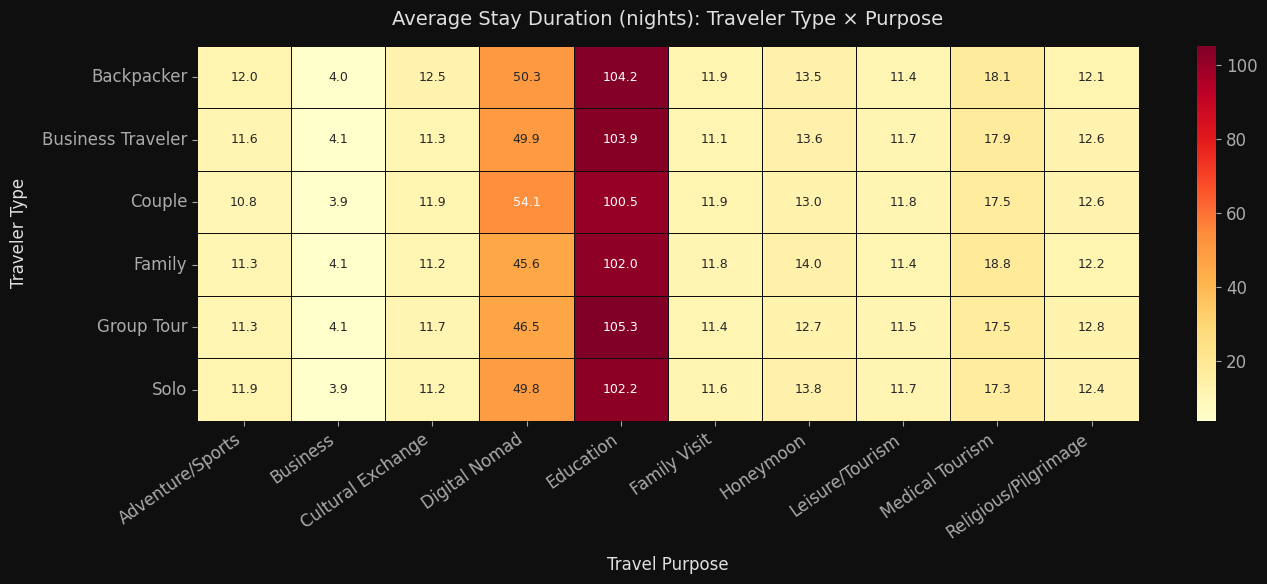

💾 Saved: heatmap_duration.png


In [25]:
# Heatmap: avg duration — traveler type × purpose
pivot = df.groupby(['traveler_type','travel_purpose'])['duration_nights'].mean().unstack().round(1)

fig, ax = plt.subplots(figsize=(14,6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, linecolor='#0f0f0f', ax=ax,
            annot_kws={'size':9})
ax.set_title('Average Stay Duration (nights): Traveler Type × Purpose', fontsize=14, pad=15)
ax.set_xlabel('Travel Purpose', labelpad=10)
ax.set_ylabel('Traveler Type', labelpad=10)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('heatmap_duration.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('💾 Saved: heatmap_duration.png')

---
## 9. The Honeymoon Paradox + Other Small Surprises

In [26]:
# Honeymoon destinations
honeymoon = df[df['travel_purpose']=='Honeymoon']
adventure = df[df['travel_purpose']=='Adventure/Sports']

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Honeymoon Hotspots', 'Adventure Destinations'])

h = honeymoon['destination_country'].value_counts().head(8).reset_index()
a = adventure['destination_country'].value_counts().head(8).reset_index()
h.columns = a.columns = ['country','count']

fig.add_trace(go.Bar(x=h['country'], y=h['count'],
                     marker_color='#e94560', name='Honeymoon'), row=1, col=1)
fig.add_trace(go.Bar(x=a['country'], y=a['count'],
                     marker_color='#48cae4', name='Adventure'), row=1, col=2)

fig.update_layout(template=PLOTLY_TEMPLATE, height=420,
                  title='Honeymoon vs Adventure — Very Different World Maps',
                  showlegend=False)
fig.show()

print(f'\n💒 Avg honeymoon duration: {honeymoon["duration_nights"].mean():.1f} nights')
print(f'🧗 Avg adventure trip duration: {adventure["duration_nights"].mean():.1f} nights')


💒 Avg honeymoon duration: 13.4 nights
🧗 Avg adventure trip duration: 11.4 nights


In [27]:
# Busiest travel months overall
monthly = df.groupby('month').size().reset_index(name='trips')
monthly['month_name'] = monthly['month'].map(
    {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
     7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'})

fig = go.Figure(go.Bar(
    x=monthly['month_name'], y=monthly['trips'],
    marker=dict(color=monthly['trips'], colorscale='Plasma', showscale=False),
    text=monthly['trips'], textposition='outside',
    textfont=dict(color='white', size=10)
))
fig.update_layout(template=PLOTLY_TEMPLATE,
                  title='Which Month Do People Travel Most? (All Years Combined)',
                  xaxis_title='Month', yaxis_title='Total Trips', height=400)
fig.show()

---
## 10. Final Observations

Here's what this dataset actually says, in plain language:

**1. The pandemic left a permanent mark — but not the one you'd expect.**  
Travel didn't just recover, it *changed*. The mix of purposes shifted. Digital Nomads tripled. Medical Tourism held steady even during 2020. The people who kept moving during the worst of it weren't the same people who took beach vacations.

**2. Families are the backbone of global tourism.**  
25% of all trips in this dataset were taken by families, every single year. They're consistent, they book longer stays, and they don't change their habits dramatically even during disruptions.

**3. Not all recovery is equal.**  
2022 was the rebound year. 2023 was the boom. But 2024 shows a slight pullback — which raises an interesting question: are we hitting a new equilibrium, or is there another dip coming?

**4. The median vs mean gap on duration is real and meaningful.**  
Most people stay 11 nights. The mean is 17.5. Group Tours and Business Travelers pull that average way up — they tend to commit to longer trips when they do travel.

**5. Pakistan shows up as a top-10 origin country.**  
496 outbound trips in this dataset from Pakistan — which puts it in the top 10 globally. The data reflects how South Asian travelers are a growing share of global tourism, particularly for Leisure and Religious purposes.

---

### What's next?

This notebook covers the descriptive layer. The next step is predictive — can we forecast travel volume using time-series models? Can we cluster travelers into behavioral segments? That's a different project, but the foundation is here.

---

*Built by [Zeba Mushtaq](https://github.com/Zeba-Mushtaq) · [Portfolio](https://zeba-portfolio.vercel.app) · [Hashnode](https://zebabuilds.hashnode.dev) · [DEV.to](https://dev.to/zebamushtaq)*  
*Dataset is synthetic — created for educational and portfolio purposes.*